The <b> K-Nearest Neighbors (KNN) classifier </b> is a simple, intuitive, and 
 
   powerful supervised machine learning algorithm used for <b>classification and regression tasks.</b>
   

What is KNN?

KNN stands for K-Nearest Neighbors.

It does not learn a model during training; instead, 

   it stores the training data and makes predictions at runtime based on the similarity (usually distance) between data points.


How It Works (Classification)

    To predict the class of a new (unknown) data point:

    Calculate the distance between the unknown point and all training points (commonly Euclidean distance).

    Pick the k nearest neighbors (i.e., the k closest points).

    Majority vote: The predicted class is the one that occurs most frequently among those k neighbors.

    Distance Metric	Usually Euclidean, but can be Manhattan, Minkowski, etc.

    Lazy Learning	KNN doesn't build a model; it "learns" at prediction time

    Non-parametric	Makes no assumptions about the data distribution

### Parametric vs Non Parametric

    Parametric models (like Linear Regression, Logistic Regression):

    Assume a specific form (e.g., a line or curve).

    Learn a fixed number of parameters (like coefficients).

    Once trained, you just use those parameters to make predictions.

    Non-parametric models (like KNN, Decision Trees):

    Do not assume any specific form for the function.

    The model size grows with the data.

    Store and use entire training data for prediction (as in KNN).

| Feature                | Prametric                     | Non-Parametric             |
| ---------------------- | ------------------------------ | -------------------------- |
| **Assumes a formula?** | ✅ Yes                          | ❌ No                       |
| **Fixed size model?**  | ✅ Yes (formula doesn’t change) | ❌ No (grows with data)     |
| **Fast prediction?**   | ✅ Yes                          | ❌ Slower (needs to search) |
| **Needs more data?**   | ❌ Not always                   | ✅ Usually yes              |

### Import modules

In [38]:
import numpy as np
import pandas as pd
from sklearn import preprocessing

import warnings
warnings.filterwarnings('ignore')

### Load data

In [39]:
data1=pd.read_csv('Iris.csv')

In [40]:
data1

,sepal length,sepal width,petal length,petal width,class
0,4.3,3.0,1.1,0.1,Iris-setosa
1,4.4,2.9,1.4,0.2,Iris-setosa
2,4.4,3.0,1.3,0.2,Iris-setosa
3,4.4,3.2,1.3,0.2,Iris-setosa
4,4.5,2.3,1.3,0.3,Iris-setosa
...,...,...,...,...,...
145,7.7,3.8,6.7,2.2,Iris-virginica
146,7.7,2.6,6.9,2.3,Iris-virginica
147,7.7,2.8,6.7,2.0,Iris-virginica
148,7.7,3.0,6.1,2.3,Iris-virginica


In [41]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  150 non-null    float64
 1   sepal width   150 non-null    float64
 2   petal length  150 non-null    float64
 3   petal width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [42]:
data1['class'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [43]:
data1['class'].value_counts()

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [44]:
data1.isna().sum()

sepal length    0
sepal width     0
petal length    0
petal width     0
class           0
dtype: int64

In [ ]:
data1.info()

In [45]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data1['class'] = le.fit_transform(data1['class'])
data1

,sepal length,sepal width,petal length,petal width,class
0,4.3,3.0,1.1,0.1,0
1,4.4,2.9,1.4,0.2,0
2,4.4,3.0,1.3,0.2,0
3,4.4,3.2,1.3,0.2,0
4,4.5,2.3,1.3,0.3,0
...,...,...,...,...,...
145,7.7,3.8,6.7,2.2,2
146,7.7,2.6,6.9,2.3,2
147,7.7,2.8,6.7,2.0,2
148,7.7,3.0,6.1,2.3,2


In [46]:
x=data1.iloc[:,0:4]
y=data1.iloc[:,4]

In [47]:
x

,sepal length,sepal width,petal length,petal width
0,4.3,3.0,1.1,0.1
1,4.4,2.9,1.4,0.2
2,4.4,3.0,1.3,0.2
3,4.4,3.2,1.3,0.2
4,4.5,2.3,1.3,0.3
...,...,...,...,...
145,7.7,3.8,6.7,2.2
146,7.7,2.6,6.9,2.3
147,7.7,2.8,6.7,2.0
148,7.7,3.0,6.1,2.3


In [48]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: class, Length: 150, dtype: int32

In [49]:
minmax=preprocessing.MinMaxScaler(feature_range=(0,1))
#minmax.fit(x).transform(x)

x = minmax.fit_transform(x)

In [50]:
x

array([[0.        , 0.41666667, 0.01694915, 0.        ],
       [0.02777778, 0.375     , 0.06779661, 0.04166667],
       [0.02777778, 0.41666667, 0.05084746, 0.04166667],
       [0.02777778, 0.5       , 0.05084746, 0.04166667],
       [0.05555556, 0.125     , 0.05084746, 0.08333333],
       [0.08333333, 0.45833333, 0.08474576, 0.04166667],
       [0.08333333, 0.58333333, 0.06779661, 0.08333333],
       [0.08333333, 0.66666667, 0.        , 0.04166667],
       [0.08333333, 0.5       , 0.06779661, 0.04166667],
       [0.11111111, 0.5       , 0.05084746, 0.04166667],
       [0.11111111, 0.5       , 0.10169492, 0.04166667],
       [0.13888889, 0.58333333, 0.10169492, 0.04166667],
       [0.13888889, 0.41666667, 0.06779661, 0.        ],
       [0.13888889, 0.58333333, 0.15254237, 0.04166667],
       [0.13888889, 0.45833333, 0.10169492, 0.04166667],
       [0.13888889, 0.41666667, 0.06779661, 0.08333333],
       [0.16666667, 0.41666667, 0.06779661, 0.04166667],
       [0.16666667, 0.45833333,

In [51]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3)

In [ ]:
x_train

In [ ]:
y_train.head(5)

# kNN Classifier

In [53]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier()

In [54]:
clf.fit(x_train,y_train)

KNeighborsClassifier()

In [55]:
#Predict on test data
y_pred=clf.predict(x_test)

In [57]:
print("Actual breast cancer : ")
print(y_test.values)

Actual breast cancer : 
[0 2 2 1 0 0 2 0 0 2 1 1 2 0 0 0 0 2 0 2 1 2 2 2 1 2 1 0 1 0 1 2 2 1 0 1 1
 2 2 2 1 0 2 2 1]


In [56]:
print("\nPredicted breast cancer : ")
print(y_pred)


Predicted breast cancer : 
[0 2 2 1 0 0 2 0 0 2 1 1 2 0 0 0 0 2 0 2 1 2 2 2 1 2 1 0 2 0 1 2 2 1 0 1 1
 2 2 2 2 0 2 2 1]


In [58]:
from sklearn.metrics import accuracy_score, recall_score,precision_score 

print("\nAccuracy score: %f" %(accuracy_score(y_test,y_pred) * 100))


Accuracy score: 95.555556


In [ ]:
from sklearn import metrics

print("Precision, Recall, Confusion matrix, in training\n")

print(metrics.classification_report(y_test, y_pred, digits=3))

In [59]:
print(metrics.confusion_matrix(y_test, y_pred))

[[14  0  0]
 [ 0 11  2]
 [ 0  0 18]]


In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

k_values = [i for i in range (1,13)]
scores = []

scaler = StandardScaler()
X = scaler.fit_transform(x)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, x, y, cv=5)
   # print(scores)
    scores.append(np.mean(score))
    
print(scores)

[0.9, 0.8800000000000001, 0.9266666666666667, 0.9333333333333333, 0.9266666666666667, 0.9266666666666667, 0.9333333333333333, 0.9466666666666667, 0.9333333333333333, 0.9466666666666667, 0.9333333333333333, 0.9400000000000001]


Text(0, 0.5, 'Accuracy Score')

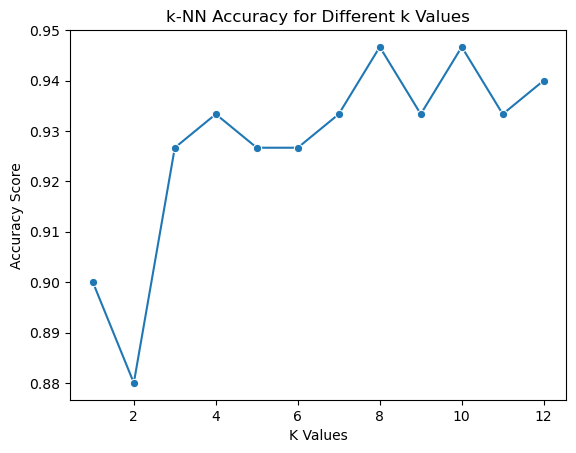

In [65]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.lineplot(x = k_values, y = scores, marker = 'o')
plt.title("k-NN Accuracy for Different k Values")
plt.xlabel("K Values")
plt.ylabel("Accuracy Score")

In [62]:
best_index = np.argmax(scores)
best_index

7

In [63]:
best_k = k_values[best_index]

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=8)

In [64]:
print(best_k)

8


In [68]:
from sklearn.metrics import accuracy_score, recall_score,precision_score 

y_pred = knn.predict(x_test)

In [69]:
accuracy = accuracy_score(y_test, y_pred)

In [70]:
print(f"Final accuracy with best k ({best_k}): {accuracy * 100:.2f}%")

Final accuracy with best k (8): 95.56%


In [71]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)
conf_mat

array([[14,  0,  0],
       [ 0, 11,  2],
       [ 0,  0, 18]], dtype=int64)

### Predict with Unknown data

To predict an unknown (new) data point using the trained k-NN model (after choosing the best k), you need to:
    Prepare the unknown sample.
    Scale it using the same scaler used for the training data (MinMaxScaler in your code).
    Use knn.predict() on the scaled input.

In [72]:
# Example unknown input (values must match feature order: sepal length, sepal width, petal length, petal width)

unknown_sample = np.array([[5.1, 3.5, 1.4, 0.2]])

unknown_sample_scaled = minmax.transform(unknown_sample)

predicted_class = knn.predict(unknown_sample_scaled)
print(predicted_class)

[0]


In [73]:
# Decode the predicted label back to original class name

predicted_label = le.inverse_transform(predicted_class)
print(f"Predicted class for the unknown sample: {predicted_label[0]}")

Predicted class for the unknown sample: Iris-setosa


cross_val_score is a function in scikit-learn that helps you check how well your model is performing, in a reliable and fair way.

If you have 100 data points and you do 10-fold cross-validation:

    The data is split into 10 equal parts (called "folds").
    
    The model is trained on 9 folds, and tested on the 1 remaining fold.
    
    This process is repeated 10 times, each time testing on a different fold.
    
    You get 10 accuracy scores, one for each fold.
    
    Then, you average them to get a more reliable accuracy estimate.

📦 cross_val_score(model, X, y, cv=10) 

model → Your ML model (e.g. KNeighborsClassifier)

X → Features (input data)

y → Labels (target/output)

cv=10 → 10-fold cross-validation

It returns a list of 10 accuracy scores (one for each fold).

🔁 Benefits of Cross-Validation:

More robust evaluation

Helps reduce bias from a single train-test split

Good for model selection (like tuning k in KNN)


### Params

Use weights='distance' if closer neighbors should have more influence.

Use p=1 for Manhattan distance, p=2 for Euclidean distance.

algorithm='auto' usually works well; it picks the best method based on your data.

| Parameter     | Description                                                                                | Example              |
| ------------- | ------------------------------------------------------------------------------------------ | -------------------- |
| `n_neighbors` | Number of neighbors to use (i.e. the "k" in KNN)                                           | `n_neighbors=3`      |
| `weights`     | How to weight the neighbors: `'uniform'` (equal) or `'distance'` (closer = more important) | `weights='distance'` |
| `algorithm`   | How to search for nearest neighbors: `'auto'`, `'ball_tree'`, `'kd_tree'`, `'brute'`       | `algorithm='auto'`   |
| `p`           | Power parameter for distance metric: `1` = Manhattan, `2` = Euclidean                      | `p=2`                |
| `metric`      | The distance metric used (`'minkowski'`, `'euclidean'`, `'manhattan'`, etc.)               | `metric='minkowski'` |
| `leaf_size`   | Size of leaf in the tree (used with `kd_tree` or `ball_tree`)                              | `leaf_size=30`       |
| `n_jobs`      | Number of CPU cores to use (-1 = all cores)                                                | `n_jobs=-1`          |


🔹 Purpose of algorithm
    
    The algorithm parameter controls how the KNN model searches for the nearest neighbors.
    
    It doesn’t affect the final prediction (result stays the same) — it only affects speed and efficiency, especially on large datasets.

| `algorithm`          | How it works                                                          | Best for                                  |
| -------------------- | --------------------------------------------------------------------- | ----------------------------------------- |
| `'auto'` *(default)* | Automatically chooses the best method based on your data and `metric` | Safe default                              |
| `'ball_tree'`        | Uses Ball Tree structure (good for low-dimensional, continuous data)  | Small to medium data                      |
| `'kd_tree'`          | Uses KD Tree structure (fast for low-dimensional numeric data)        | Data with <20 features                    |
| `'brute'`            | Brute-force search (checks all points)                                | Very high-dimensional data or sparse data |
